In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy.stats as stats
import json

In [2]:
# import data from json file
def get_data(path):
    with open(path, 'r') as file:
        data = json.load(file)
    return data

In [3]:
# Import data
data_path = '/Users/chattarinpoungtubtim/Zeng2021/data/phase1_pilot_data/P_11307.txt'

data = get_data(data_path)



In [4]:
# select only test trials
start_idx = -9
end_idx = -2
test_dict = data['events'][-9:-2]

In [5]:
# get gist data
def get_gist_data(test_dict):
    true_gist_x = test_dict[0]['trueCenter']['x']
    true_gist_y = test_dict[0]['trueCenter']['y']
    resp_gist_x = test_dict[0]['response']['x']
    resp_gist_y = test_dict[0]['response']['y']
    return true_gist_x, true_gist_y, resp_gist_x, resp_gist_y

In [6]:
# get item data
def get_ind_data(test_dict):
    num_dot  = len(test_dict)-1
    true_x = np.zeros(num_dot)
    true_y = np.zeros(num_dot)
    resp_x = np.zeros(num_dot)
    resp_y = np.zeros(num_dot)
    for i in range(num_dot):
        true_x[i] = test_dict[i+1]['trueLoc']['x']
        true_y[i] = test_dict[i+1]['trueLoc']['y']
        resp_x[i] = test_dict[i+1]['response']['x']
        resp_y[i] = test_dict[i+1]['response']['y']
    return true_x, true_y, resp_x, resp_y

In [7]:
true_gist_x, true_gist_y, resp_gist_x, resp_gist_y = get_gist_data(test_dict)
true_x, true_y, resp_x, resp_y = get_ind_data(test_dict)

In [8]:
def get_dist(true_x,true_y,resp_x,resp_y):
    #get x dist
    x_dist = np.power(true_x - resp_x, 2)
    #get y dist  
    y_dist = np.power(true_y - resp_y, 2)
    #sum 
    sum_dist = (np.sqrt(x_dist + y_dist))

    return sum_dist

In [9]:
# get error
error_ind = get_dist(true_x,true_y,resp_x,resp_y)
avg_error_ind = np.average(error_ind)
error_gist = get_dist(true_gist_x,true_gist_y,resp_gist_x,resp_gist_y)

In [10]:
# get bias
bias = (error_ind - get_dist(true_gist_x,true_gist_y,resp_x,resp_y))/error_ind
avg_bias = np.average(bias)

# Loop over subjects

In [23]:
all_data_path = '/Users/chattarinpoungtubtim/Zeng2021/data/phase1_pilot_data/'
#remove .DS
all_filename = sorted(os.listdir(all_data_path))[1:]
num_sub = len(all_filename)
#create array to save data
all_error_ind = np.zeros(num_sub)
all_error_gist = np.zeros(num_sub)
all_bias = np.zeros(num_sub)

In [79]:
# select only test trials
start_idx = -9
end_idx = -2
# arrays to check gist response
good_gist_loc = np.zeros(num_sub)
# store elapse time
# loop over filenam
all_task_time = np.zeros(num_sub)
for sub in range(num_sub):
    filename = all_filename[sub]
    file_path = all_data_path + filename
    data = get_data(file_path)
    test_dict = data['events'][start_idx:end_idx]

    # get stim location and response
    true_gist_x, true_gist_y, resp_gist_x, resp_gist_y = get_gist_data(test_dict)
    true_x, true_y, resp_x, resp_y = get_ind_data(test_dict)

    # get error
    error_ind = get_dist(true_x,true_y,resp_x,resp_y)
    avg_error_ind = np.average(error_ind)
    avg_error_gist = get_dist(true_gist_x,true_gist_y,resp_gist_x,resp_gist_y)

    # get bias
    bias = (get_dist(true_gist_x,true_gist_y,true_x,true_y)) - get_dist(true_gist_x,true_gist_y,resp_x,resp_y)/error_ind
    avg_bias = np.average(bias)

    # collect data
    all_error_ind[sub] = avg_error_ind
    all_error_gist[sub] = avg_error_gist
    all_bias[sub] = avg_bias

    # check whether gist response is within landmarks
    max_x = np.max(true_x)
    min_x = np.min(true_x)
    max_y = np.max(true_y)
    min_y = np.min(true_y)
    good_gist_x = resp_gist_x >= min_x and resp_gist_x <= max_x
    good_gist_y = resp_gist_y >= min_y and resp_gist_y <= max_y
    good_gist_loc[sub] = int(good_gist_x and good_gist_y)

    #get time
    total_time = ((data['events'][-2]['t'] - data['events'][0]['t']) / 60000)  # turn millisec into minutes
    all_task_time[sub] = total_time

# time spent in an exp.

In [80]:
print('average time spent = ' + str(np.median(all_task_time)) + ' mins')

average time spent = 4.389916666666666 mins


In [ ]:
# exclusion criteria 1 : bad ind memory performance
avg_error_ind = np.average(all_error_ind)
std_error_ind = np.std(all_error_ind)
low_error_ind = avg_error_gist + (3 * std_error_ind)
# exclusion criteria 2 : bad gist memory performance
avg_error_gist = np.average(all_error_gist)
std_error_gist = np.std(all_error_gist)
low_error_gist = avg_error_gist + (3 * std_error_gist)
# combine 1 and 2
good_avg_perf = np.logical_or(all_error_ind <= low_error_ind, all_error_gist <= all_error_gist)
# combine with good gist resp. and time lim.
time_lim = 20
within_time = all_task_time <= time_lim
good_sub_all = np.logical_and(np.logical_and(good_gist_loc,good_avg_perf),within_time)

In [ ]:
# select only good data
clean_error_ind = all_error_ind[good_sub_all]
clean_error_gist = all_error_gist[good_sub_all]

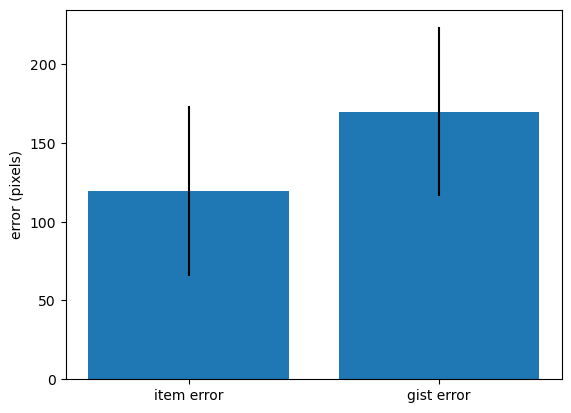

In [ ]:
# compare ind and gist error
all_error_labels = ['item error', 'gist error']
all_error_mean = [np.mean(clean_error_ind), np.mean(clean_error_gist)]
avg_error_both = (clean_error_ind + clean_error_gist)/2
demean_error_ind = clean_error_ind - avg_error_both
demean_error_gist = clean_error_gist - avg_error_both
all_error_std = [np.std(demean_error_ind), np.std(demean_error_gist)]
plt.bar(all_error_labels, all_error_mean,yerr=all_error_std)
plt.ylabel('error (pixels)')
plt.show()

# Compare with data from Zeng et al., 2021

In [34]:
# import data
zeng_data_p1 = pd.read_csv('/Users/chattarinpoungtubtim/Downloads/code_data/EXP1/1w_data1.csv')

In [39]:
zeng_error_ind = zeng_data_p1.dropna(subset=['ID'])['dind'].to_numpy()
zeng_error_gist= zeng_data_p1.dropna(subset=['ID'])['dgist'].to_numpy()

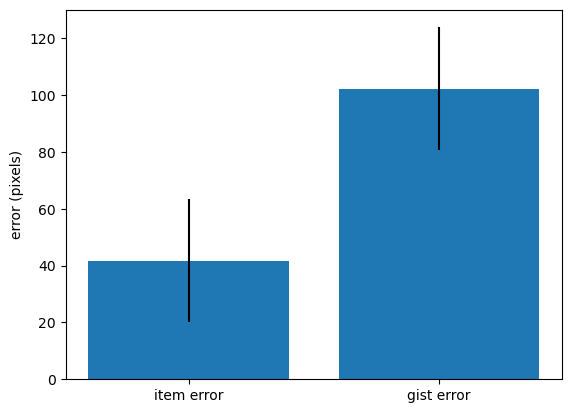

In [40]:
# compare ind and gist error
all_error_labels = ['item error', 'gist error']
zeng_error_mean = [np.mean(zeng_error_ind), np.mean(zeng_error_gist)]
zeng_error_both = (zeng_error_ind + zeng_error_gist)/2
demean_error_ind = zeng_error_ind - zeng_error_both
demean_error_gist = zeng_error_gist - zeng_error_both
all_error_std = [np.std(demean_error_ind), np.std(demean_error_gist)]
plt.bar(all_error_labels, zeng_error_mean,yerr=all_error_std)
plt.ylabel('error (pixels)')
plt.show()